In [25]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import BaseMessage
from typing import TypedDict,Annotated,Any,Dict
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama
from langchain_community.vectorstores import FAISS
from langgraph.graph.message import add_messages
import os 
from langchain_core.tools import tool
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_text_splitters import RecursiveCharacterTextSplitter
from __future__ import annotations
import _sqlite3
import tempfile

In [2]:
docs=PyPDFLoader(r"C:\Users\PC\OneDrive\Documents\Deep dive into DL.pdf").load()
print(len(docs))

1151


In [5]:
# get chunks=
chunks=RecursiveCharacterTextSplitter(chunk_size=10000,chunk_overlap=63).split_documents(docs)
print(len(chunks))

1149


In [10]:
embediing=HuggingFaceEmbeddings(model_name='all-miniLm-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [11]:
vectorestore=FAISS.from_documents(docs,embedding=embediing)

In [18]:
retriever = vectorestore.as_retriever(
            search_type="similarity", search_kwargs={"k": 4}
        )

In [72]:
#llm=ChatOllama(model='qwen2.5:3b',)

llm = ChatOllama(
    model="qwen2.5:3b",
    base_url="http://127.0.0.1:11434",
    temperature=0,
    streaming=False,
)

In [73]:
result=retriever.invoke('what is cnn')
print(result[1].page_content)

287 Multi-Branch Networks (GoogLeNet)
130 Discussions 130.
8.4 Multi-Branch Networks (GoogLeNet)
In 2014,GoogLeNetwon the ImageNet Challenge (Szegedyetal., 2015), using a structure
that combined the strengths of NiN (Linet al., 2013), repeated blocks (Simonyan and Zis-
serman, 2014), and a cocktail of convolution kernels. It was arguably also the first network
that exhibited a clear distinction among the stem (data ingest), body (data processing), and
head (prediction) in a CNN. This design pattern has persisted ever since in the design of
deep networks: thestem is given by the first two or three convolutions that operate on the
image. They extract low-level features from the underlying images. This is followed by a
body of convolutional blocks. Finally, thehead maps the features obtained so far to the
required classification, segmentation, detection, or tracking problem at hand.
ThekeycontributioninGoogLeNetwasthedesignofthenetworkbody. Itsolvedtheprob-
lem of selecting convolution ke

In [74]:
@tool
def rag_tool(query):
    """use this tool for query that ask from retriver """
    result=retriever.invoke(quer)
    context=[d.page_content for d in result]
    metadata=[d.metadata for d in result]

    return{'query':query,
           'context':context,
           'metadata':metadata}

In [75]:
tools=[rag_tool]
llm_with_tool=llm.bind_tools(tools)
tole_node=ToolNode(tools=tools)

In [76]:
class chatestate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [77]:
# cree chat node
def chat_node(state:chatestate):
    messages=state['messages']
    response=llm_with_tool.invoke(messages)
    return{
        'messages':[response]
           }

In [78]:
graphe=StateGraph(chatestate)

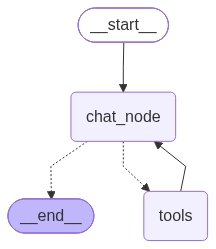

In [79]:
graphe.add_node('chat_node',chat_node)
graphe.add_node('tools',tole_node)
graphe.add_edge(START,'chat_node')
graphe.add_conditional_edges('chat_node',tools_condition)
graphe.add_edge('tools','chat_node')
chatbot=graphe.compile()
chatbot

In [82]:
from langchain.messages import HumanMessage
user={'message':[HumanMessage(content='useing the pdf explain neural network')]}
answer=chatbot.invoke(user)
print(answer['message'][-1].content)

Ollama returned empty response with done_reason='load'.This typically indicates the model was loaded but no content was generated. Skipping this response.


ValueError: No data received from Ollama stream.

In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen2.5:3b",
    base_url="http://127.0.0.1:11434",
    temperature=0,
    streaming=False,
)


response = llm.invoke("What is a neural network?")

print(response.content)

A neural network is a type of machine learning model inspired by the structure and function of the human brain. It consists of layers of interconnected "neurons" that process information in a way similar to how neurons work in biological brains.

Here are some key points about neural networks:

1. Structure: Neural networks typically consist of an input layer, one or more hidden layers, and an output layer. Each layer contains multiple nodes (or neurons), which receive inputs from the previous layer and send outputs to the next layer.

2. Learning process: During training, a neural network adjusts its internal parameters (weights) based on the error between its predictions and actual data labels. This is done through algorithms like backpropagation, where the model learns by minimizing this error over multiple iterations or epochs.

3. Types of Neural Networks:
   - Feedforward networks: The most common type, where information moves in only one direction from input to output.
   - Recu